<a href="https://colab.research.google.com/github/sethkipsangmutuba/Bayesian-Neural-Network/blob/Deeplearning/Note_1_Data_Mining_%26_Warehousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Note 1: Foundations and Core Tasks in Data Mining**

---
##Seth Kipsang

## **1. Introduction to Data Mining**
A high-level conceptual entry point into the discipline, covering its purpose, analytical scope, and the evolution from traditional databases to knowledge discovery in large-scale data environments.

---

## **2. Counting Co-Occurrences**
Fundamental techniques for identifying statistical regularities within large datasets.

### **2.1 Frequent Itemsets**
Core concepts of itemset support, pattern frequency, and the role of frequent itemsets in market basket analysis and transactional mining.

### **2.2 Iceberg Queries**
Efficient computation of high-support aggregates by focusing only on the “top” portion of multidimensional data cubes.

---

## **3. Mining for Rules**
From frequent patterns to interpretable rules that capture structural dependencies.

### **3.1 Association Rules**
Support, confidence, lift, and related metrics for discovering meaningful co-occurrence relationships.

### **3.2 Algorithms for Association Rule Discovery**
Candidate generation, pruning, and scalable search strategies.

### **3.3 Association Rules and ISA Hierarchies**
Integration of concept hierarchies to produce more general, semantically rich rules.

### **3.4 Generalized Association Rules**
Domain-constrained rules that leverage taxonomies or attribute generalization.

### **3.5 Sequential Patterns**
Extraction of temporally ordered patterns across sequence or event-log data.

### **3.6 Association Rules for Prediction**
Using rule sets as predictive models for classification or risk estimation.

### **3.7 Bayesian Networks**
Probabilistic graphical structures for modelling causal dependencies and performing inference.

### **3.8 Classification and Regression Rules**
Rule-based supervised learning methods for categorical and continuous response variables.

---

## **4. Tree-Structured Rules**

### **4.1 Decision Trees**
Hierarchical partitioning of data using splitting criteria such as entropy or Gini index.

### **4.2 Algorithms for Building Decision Trees**
Greedy tree induction, pruning strategies, handling noise, and avoiding overfitting.

---

## **5. Clustering**
Unsupervised methods for discovering structure in unlabeled data.

### **5.1 A Clustering Algorithm**
Principles of distance-based partitioning and iterative refinement.

---

## **6. Similarity Search over Sequences**

### **6.1 Algorithms for Similar Sequence Detection**
Methods for comparing time series, DNA sequences, and other ordered data, using distance metrics and dynamic alignment techniques.

---

## **7. Additional Data Mining Tasks**
A survey of extended topics such as anomaly detection, dimensionality reduction, graph mining, and text/web mining.

---

## **8. Points to Review**
Synthesis of key concepts introduced in the lecture, reinforcing the distinction between pattern discovery, rule induction, supervised vs. unsupervised learning, and the algorithmic foundations underlying scalable data mining.


# **Lecture 1: Introduction to Data Mining**

> *“The secret of success is to know something nobody else knows.”*  
> — **Aristotle Onassis**

Data mining is the systematic process of discovering meaningful patterns, trends, or correlations in large datasets to inform and guide decisions about future actions. Its strength lies not only in automation but also in its ability to surface unexpected insights—patterns that prompt new hypotheses and can be validated through decision-support tools or statistical analysis.

As data grows in volume and complexity, the scope of data mining has expanded dramatically. Modern commercial platforms now support large-scale analytical tasks across industries, reflecting the field’s strategic importance.

This lecture introduces foundational concepts and tasks in data mining, including:

- Counting co-occurring items in datasets (Section 24.2)  
- Rule discovery (Section 24.3)  
- Tree-structured rule representation (Section 24.4)  
- Clustering patterns (Section 24.5)  
- Sequence similarity searches (Section 24.6)  
- Overview of additional mining tasks (Section 24.7)

---

## **24.1 Introduction to Data Mining**

Data mining intersects several analytical disciplines:

### **• Exploratory Data Analysis (EDA)**  
Provides visualization and summary techniques for detecting structure and variation in data.

### **• Knowledge Discovery & Machine Learning**  
Offers algorithmic tools for pattern recognition, prediction, and decision-making.

What distinguishes data mining is **scale**. Traditional EDA and AI techniques often struggle when datasets grow extremely large. In contrast, data mining algorithms must remain efficient across massive datasets. An algorithm is termed *scalable* when its complexity grows linearly—or near-linearly—with dataset size under realistic memory and storage constraints. Achieving this often requires adapting existing algorithms or designing entirely new ones.

---

## **Data Mining as an Analytical Continuum**

Data mining operates along a spectrum of analytical sophistication:

- **SQL Queries:**  
  Low-level structured retrieval based on relational algebra.

- **OLAP Queries:**  
  Multidimensional queries for exploratory analysis and aggregation.

- **Data Mining:**  
  High-level, pattern-oriented analysis designed to extract relationships and trends not obvious through direct queries.

In typical practice, analysts specify mining tasks through simple, high-level parameters. Specialized algorithms then handle the full complexity of execution, keeping the user experience streamlined.

---

## **Challenges in Practical Data Mining**

Real-world datasets introduce several complications:

- **Noise, Missing Values, and Inconsistencies:**  
  Preprocessing is essential to ensure data quality.

- **Relevance Filtering:**  
  Analysts must identify which tuples and attributes should participate in the mining task.

- **Interpretation and Validation:**  
  Results must be interpreted carefully, validated against domain knowledge, and refined iteratively.

---

## **The Knowledge Discovery in Databases (KDD) Process**

Data mining forms one stage within the broader **KDD** pipeline:

### **1. Data Selection**  
Identify the target dataset and attributes relevant to the analysis objective.

### **2. Data Cleaning and Transformation**  
Remove noise and outliers, normalize values, engineer new attributes, and restructure data as required by mining algorithms. Denormalization may be applied to improve performance.

### **3. Data Mining**  
Execute algorithms to extract patterns, associations, clusters, or other structural insights.

### **4. Evaluation and Interpretation**  
Translate results into interpretable knowledge using visualization or decision-support tools.

Notably, **KDD is iterative**. Insights from evaluation often lead analysts back to earlier steps—refining data, redefining the problem, or adjusting algorithmic parameters.

---

In this lecture, we concentrate on **core mining algorithms** relevant to specific tasks. Broader considerations in KDD process design and operational deployment will be explored in later sessions.


# **24.2 Counting Co-Occurrences**

Counting co-occurring items is a foundational data mining task, widely used in applications such as **market basket analysis**. A *market basket* represents the collection of items a customer purchases in a single transaction—whether in-store, online, or through catalog orders.

**Goal:**  
Identify items that are frequently purchased together to guide decisions on store layout, promotional strategies, product placement, and cross-selling.

---

## **Example Dataset (Purchases Relation)**

| transid | custid | date     | item  | qty |
|--------|--------|----------|-------|-----|
| 111    | 201    | 5/1/99   | pen   | 2   |
| 111    | 201    | 5/1/99   | ink   | 1   |
| 111    | 201    | 5/1/99   | milk  | 3   |
| 111    | 201    | 5/1/99   | juice | 6   |
| 112    | 105    | 6/3/99   | pen   | 1   |
| 112    | 105    | 6/3/99   | ink   | 1   |
| 112    | 105    | 6/3/99   | milk  | 1   |
| 113    | 106    | 5/10/99  | pen   | 1   |
| 113    | 106    | 5/10/99  | milk  | 1   |
| 114    | 201    | 6/1/99   | pen   | 2   |
| 114    | 201    | 6/1/99   | ink   | 2   |
| 114    | 201    | 6/1/99   | juice | 4   |

---

# **24.2.1 Frequent Itemsets**

### **Definitions**

- **Itemset:**  
  A set of items.

- **Support:**  
  The fraction of transactions containing all items in the itemset.

---

### **Examples**

- `{pen, ink}` occurs in **3/4** transactions → **support = 75%**
- `{milk, juice}` occurs in **1/4** transactions → **support = 25%**

Itemsets whose support meets or exceeds the **minimum support threshold (minsup)** are called **frequent itemsets**.

---

## **Example (minsup = 70%)**

**Frequent itemsets:**  
`{pen}`, `{ink}`, `{milk}`, `{pen, ink}`, `{pen, milk}`

---

# **Algorithmic Approach: Apriori**

A classic method for discovering frequent itemsets is the **Apriori algorithm**, which uses an iterative, level-wise search strategy.

---

## **Iterative, Level-Wise Generation**

### **Step 1: Identify frequent 1-itemsets.**  
Compute the support of each individual item.

### **Step 2: Generate candidate k+1-itemsets.**  
Combine frequent k-itemsets to propose larger candidates.

### **Step 3: Scan the dataset.**  
Compute support for each candidate and keep only those meeting minsup.

### **Step 4: Terminate when no new frequent itemsets emerge.**

---

# **Key Optimization: The Apriori Property**

> **Every subset of a frequent itemset must itself be frequent.**

This principle enables **pruning**:

- If any subset of a candidate itemset is not frequent,  
  **discard the candidate without scanning the database**.

This dramatically reduces computation and improves scalability.

---

# **Illustrative Iterations (minsup = 70%)**

## **Level 1 (Frequent 1-itemsets)**  
`{pen}`, `{ink}`, `{milk}`

---

## **Level 2 (Candidate 2-itemsets)**

**Candidates:**  
`{pen, ink}`, `{pen, milk}`, `{pen, juice}`, `{ink, milk}`, `{ink, juice}`, `{milk, juice}`

**Frequent:**  
`{pen, ink}`, `{pen, milk}`

---

## **Level 3 (Candidate 3-itemsets)**

**Candidates:**  
`{pen, ink, milk}`, `{pen, ink, juice}`, `{pen, milk, juice}`

**Frequent:**  
None (all pruned using the Apriori property)

---

# **Takeaways for Implementation**

- Data is often **denormalized** before mining to simplify itemset extraction.
- Frequent itemset mining is **iterative**, building larger itemsets from smaller ones.
- **Subset-based pruning** (Apriori property) improves efficiency.
- The method scales effectively to large datasets and higher-order itemsets.



In [128]:
import warnings

# Suppress all DeprecationWarnings (including datetime warnings)
warnings.simplefilter(action='ignore', category=DeprecationWarning)


##Load & Process Groceries Transactions

# Objective

Convert the **R Groceries transaction dataset** into a Python-friendly, **one-hot encoded DataFrame (`df`)** for data mining tasks such as **association rule mining**.

---

## **Steps Overview**

1. **R Integration:**  
   - Use `rpy2` to bridge Python and R.  
   - Load the **`arules` package** and the **Groceries dataset** directly from R.

2. **Transactions Extraction:**  
   - `LIST(Groceries)` converts each transaction to a **list of purchased items**.

3. **Python Conversion:**  
   - `transactions = [list(x) for x in transactions_r]` transforms the R list of vectors into a **Python list of lists**.

4. **One-Hot Encoding:**  
   - Use `TransactionEncoder` from **mlxtend** to convert each transaction into a **boolean vector**:  
     - `True` → item purchased  
     - `False` → item not purchased

5. **Resulting DataFrame:**  
   - `df` has shape `(9835, 169)` → 9,835 transactions (rows) × 169 items (columns)  
   - Each cell indicates whether a **customer purchased that item**

---

## **Use in Data Mining**

- **Rows:** Transactions  
- **Columns:** Items  
- **Suitable for:**  
  - Frequent itemset mining  
  - Association rules  
  - Generalized rules  
  - Clustering

---

## **Key Insight**

One-hot encoding transforms **categorical basket data** into a **structured, machine-readable format**, enabling scalable mining of **co-occurrence patterns**.


In [129]:
# Imports
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri

# Enable automatic R -> Pandas conversion
pandas2ri.activate()

# Install and load arules in R
robjects.r('''
if(!require(arules)) install.packages("arules", repos="https://cloud.r-project.org")
library(arules)
data("Groceries")
''')

#  Extract transactions as a list of character vectors in R
transactions_r = robjects.r('LIST(Groceries)')  # LIST converts to a list of item vectors

#  Convert to Python list of lists
transactions = [list(x) for x in transactions_r]

# One-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
df


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9833,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


- **Structure:**  
  `transactions` is a **list of lists**, where each sublist represents a transaction containing items bought by a customer.

- **Transaction Encoding:**  
  `TransactionEncoder` has converted the transactions into a **Boolean DataFrame (`df`)**:  
  - **Columns:** Represent individual items  
  - **Rows:** Represent transactions  
  - **Values:** `True` if the item was bought in that transaction, `False` otherwise

- **Dataset Dimensions:**  
  - **Rows:** 9,835 (transactions)  
  - **Columns:** 169 (distinct items)  

- **Compatibility:**  
  Matches the structure of the original **R Groceries dataset**, enabling frequent itemset mining, association rule generation, and other data mining tasks.


# Mining Frequent Itemsets

---

## **Objective**

Identify **item combinations** that appear frequently in transactions.

---

## **Key Steps**

### **Input**

- $df$ → One-hot encoded DataFrame  
  - **Rows:** Transactions ($T_1, T_2, ..., T_n$)  
  - **Columns:** Items ($i_1, i_2, ..., i_m$)  
  - $True$ → Item purchased in transaction  

### **Apriori Algorithm**

- Goal: Find all **itemsets $I \subseteq \{i_1, i_2, ..., i_m\}$** whose **support** satisfies:

$$
support(I) = \frac{\text{Number of transactions containing all items in } I}{\text{Total number of transactions}} \ge min\_support
$$

- `use_colnames=True` ensures **actual item names** are used instead of column indices

### **Output**

- $frequent\_itemsets$ contains:  
  - $itemsets$ → Combination of items $I$  
  - $support(I)$ → Proportion of transactions containing $I$  

### **Example Interpretation**

- Itemset $\{beef\}$ has:

$$
support(\{beef\}) = 0.052466
$$

→ ~5.25% of transactions include beef  

- Larger itemsets like $\{whole\ milk, yogurt, root\ vegetables\}$ reveal **co-purchasing patterns**.

---

## **Key Insight**

- **Frequent itemsets** are the foundation for **association rules**  
- Mining larger itemsets uncovers patterns useful for:  
  - Promotions  
  - Product placement  
  - Cross-selling strategies


In [130]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# df is already one-hot encoded:
# Each column = item, each row = transaction (True if item bought)

#  Generate frequent itemsets
min_support = 0.01  # e.g., 1% support threshold
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.033452,(UHT-milk)
1,0.017692,(baking powder)
2,0.052466,(beef)
3,0.033249,(berries)
4,0.026029,(beverages)
...,...,...
328,0.011998,"(whole milk, root vegetables, tropical fruit)"
329,0.014540,"(whole milk, yogurt, root vegetables)"
330,0.010473,"(soda, yogurt, whole milk)"
331,0.015150,"(yogurt, whole milk, tropical fruit)"


# Co-Occurrences

---

## **Purpose**

Identify **sets of items frequently bought together**.

---

## **Itemset Length**

- Let an **itemset** be $I = \{i_1, i_2, ..., i_k\}$  
- **Length** of the itemset: $$|I| = k$$  
- Helps distinguish **single items** ($k=1$) from **combinations** ($k \ge 2$)

---

## **Co-Occurrences**

- Focus on **itemsets with $$|I| \ge 2$$**  
- Support of an itemset $I$ is defined as:

$$
support(I) = \frac{\text{Number of transactions containing all items in } I}{\text{Total number of transactions}}
$$

- Itemsets with **support ≥ min\_support** are considered **frequent**.

---

## **Insight**

- **Co-occurring items** form the basis for **association rules**  
- For a rule $X \Rightarrow Y$, where $X, Y \subseteq I$ and $X \cap Y = \emptyset$, confidence is:

$$
confidence(X \Rightarrow Y) = \frac{support(X \cup Y)}{support(X)}
$$

- Highlights potential **cross-selling opportunities** by showing which items are often purchased together.


In [131]:
# Add a column for the length of each itemset (optional but useful)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Step 2: Count co-occurrences
# Co-occurrence = support of itemsets of size 2+
co_occurrences = frequent_itemsets[frequent_itemsets['length'] >= 2]
co_occurrences

,support,itemsets,length
88,0.019725,"(beef, other vegetables)",2
89,0.013625,"(beef, rolls/buns)",2
90,0.017387,"(beef, root vegetables)",2
91,0.021251,"(beef, whole milk)",2
92,0.011693,"(beef, yogurt)",2
...,...,...,...
328,0.011998,"(whole milk, root vegetables, tropical fruit)",3
329,0.014540,"(whole milk, yogurt, root vegetables)",3
330,0.010473,"(soda, yogurt, whole milk)",3
331,0.015150,"(yogurt, whole milk, tropical fruit)",3


# Association Rules

---

## **Purpose**

Discover **relationships between items** in transactions.

---

## **Rule Format**

- Represented as: $LHS \Rightarrow RHS$  
- Example: $\{bread\} \Rightarrow \{butter\}$

---

## **Confidence**

- Measures **how often RHS occurs when LHS is present**:

$$
confidence(LHS \Rightarrow RHS) = \frac{support(LHS \cup RHS)}{support(LHS)}
$$

- Threshold (e.g., 0.3) filters **meaningful rules** from all possible combinations

---

## **Insight**

- **High-confidence rules** indicate strong associations  
- Useful for:  
  - Promotions  
  - Recommendations  
  - Inventory planning


In [132]:
# Generate association rules
# Confidence metric shows how often items occur together
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(other vegetables),0.052466,0.193493,0.019725,0.375969,1.943066,1.0,0.009574,1.292416,0.512224,0.087191,0.226255,0.238957
1,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
2,(beef),(whole milk),0.052466,0.255516,0.021251,0.405039,1.585180,1.0,0.007845,1.251315,0.389597,0.074113,0.200841,0.244103
3,(berries),(other vegetables),0.033249,0.193493,0.010269,0.308869,1.596280,1.0,0.003836,1.166938,0.386391,0.047440,0.143056,0.180971
4,(berries),(whole milk),0.033249,0.255516,0.011795,0.354740,1.388328,1.0,0.003299,1.153774,0.289329,0.042584,0.133279,0.200450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,"(soda, yogurt)",(whole milk),0.027351,0.255516,0.010473,0.382900,1.498535,1.0,0.003484,1.206423,0.342037,0.038447,0.171103,0.211943
121,"(yogurt, tropical fruit)",(whole milk),0.029283,0.255516,0.015150,0.517361,2.024770,1.0,0.007668,1.542528,0.521384,0.056184,0.351714,0.288326
122,"(whole milk, tropical fruit)",(yogurt),0.042298,0.139502,0.015150,0.358173,2.567516,1.0,0.009249,1.340701,0.637483,0.090909,0.254122,0.233387
123,"(whipped/sour cream, whole milk)",(yogurt),0.032232,0.139502,0.010880,0.337539,2.419607,1.0,0.006383,1.298943,0.606250,0.067636,0.230143,0.207764


# Sorting Association Rules

---

## **Purpose**

Prioritize **strongest association rules** for actionable insights.

---

## **Sorting Criteria**

- Sort rules by one or more metrics:  
  - **Confidence**: Likelihood that $RHS$ occurs given $LHS$  
  - **Lift**: Measures how much more often $LHS$ and $RHS$ occur together than expected if independent:

$$
lift(LHS \Rightarrow RHS) = \frac{support(LHS \cup RHS)}{support(LHS) \cdot support(RHS)}
$$

- Example: Sorting descending by `confidence` and `lift` ensures the **most reliable and impactful rules** are prioritized.

---

## **Insight**

- Sorting helps **identify top rules** for:  
  - Marketing strategies  
  - Product bundling  
  - Cross-selling opportunities


In [133]:
# Sort rules by confidence or lift
rules_sorted = rules.sort_values(by=['confidence', 'lift'], ascending=False)
rules_sorted

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
74,"(root vegetables, citrus fruit)",(other vegetables),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903
96,"(root vegetables, tropical fruit)",(other vegetables),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062
79,"(curd, yogurt)",(whole milk),0.017285,0.255516,0.010066,0.582353,2.279125,1.0,0.005649,1.782567,0.571107,0.038313,0.439011,0.310874
71,"(other vegetables, butter)",(whole milk),0.020031,0.255516,0.011490,0.573604,2.244885,1.0,0.006371,1.745992,0.565878,0.043512,0.427260,0.309285
118,"(root vegetables, tropical fruit)",(whole milk),0.021047,0.255516,0.011998,0.570048,2.230969,1.0,0.006620,1.731553,0.563627,0.045350,0.422484,0.308502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,(yogurt),(other vegetables),0.139502,0.193493,0.043416,0.311224,1.608457,1.0,0.016424,1.170929,0.439613,0.149930,0.145977,0.267804
6,(bottled water),(whole milk),0.110524,0.255516,0.034367,0.310948,1.216940,1.0,0.006126,1.080446,0.200417,0.103617,0.074456,0.222724
97,"(other vegetables, whole milk)",(root vegetables),0.074835,0.108998,0.023183,0.309783,2.842082,1.0,0.015026,1.290900,0.700572,0.144304,0.225347,0.261235
3,(berries),(other vegetables),0.033249,0.193493,0.010269,0.308869,1.596280,1.0,0.003836,1.166938,0.386391,0.047440,0.143056,0.180971


# **24.2.2 Iceberg Queries**

## **Concept**

An iceberg query retrieves only those groups in a dataset whose aggregated measure exceeds a specified threshold, resembling the idea that only the “tip of the iceberg” is visible. This is especially useful when the total number of potential groups is extremely large, but only a small subset meets the required threshold.

---

## **Example Scenario**

- **Dataset:** Purchases relation (market basket transactions)  
- **Task:** Find all `(custid, item)` pairs where the total quantity purchased (**SUM(qty)**) is greater than 5.

In practice, although many such pairs may exist, only a few satisfy the threshold. Efficient computation becomes critical to avoid exhaustive processing.

---

## **General Structure of an Iceberg Query**

An iceberg query aggregates over selected attributes and retains only the groups whose aggregate value is at least the threshold.

Typical form:

SELECT R.A1, …, R.Ak, aggr(R.B)  
FROM Relation R  
GROUP BY R.A1, …, R.Ak  
HAVING aggr(R.B) ≥ threshold

---

## **Key Insights**

### **Traditional Execution**
1. Compute aggregation for every possible group.  
2. Apply the HAVING clause to filter those failing the threshold.

This approach is inefficient when the dataset is large and the group space is combinatorial.

---

### **Efficiency via the A Priori Property**

The optimization follows the same logic as in frequent itemset mining:

**If a group does not meet the threshold in any of its components, it cannot meet the threshold when combined with others.**

Implications:

- Consider only custids whose total purchased quantity meets the threshold.
- Consider only items whose aggregate quantity meets the threshold.
- Form combinations only from these viable candidates.

This drastically reduces computation by pruning unpromising groups early.

---

## **Evaluation Strategy**

### **Step 1: Independent Candidate Identification**
Filter individual attribute values (e.g., custids, items) whose aggregated totals exceed the threshold.

### **Step 2: Candidate Combination**
Cross product only among the filtered attribute values to generate (custid, item) pairs.

### **Step 3: Counter Maintenance**
Maintain group counters only for combinations that survive filtering at all levels.

This mirrors the iterative, bottom-up filtering strategy of the Apriori algorithm.

---

## **Practical Considerations**

Despite pruning, the number of candidate groups may still remain large. Techniques that enhance scalability include:

- Sampling-based estimation  
- Hash-based aggregation  
- Buffer management optimizations  
- Parallel and distributed execution (e.g., MapReduce, Spark)

---

Iceberg queries are central to large-scale data mining because they combine SQL-based aggregation with efficient pruning strategies. By evaluating only the most promising groups, they support scalable analytics over massive datasets and form the backbone of many pattern-discovery and summary-mining algorithms.


# Transaction Quantities Simulation

---

## **Objective**

Convert **boolean transaction data** into **quantities** for further analysis.

---

## **Approach**

- Original $df$ is **one-hot encoded**:  

$$
df_{ij} =
\begin{cases}
True & \text{if item } i_j \text{ was purchased in transaction } T_i \\
False & \text{otherwise}
\end{cases}
$$

- Assume **quantity = 1** for each purchased item:  

$$
quantity_{ij} =
\begin{cases}
1 & df_{ij} = True \\
0 & df_{ij} = False
\end{cases}
$$

- Resulting DataFrame `quantities` contains **integer counts** for each item in each transaction:

  - **Rows:** Transactions  
  - **Columns:** Items  
  - **Values:** Quantity purchased


In [134]:
import pandas as pd

# Simulate quantities for each transaction
# Currently df is boolean (True/False), let's assume quantity = 1 if item purchased
quantities = df.astype(int)
quantities


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,1,0,0
9831,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9832,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
9833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Iceberg Query: Item Purchase Threshold

---

## **Objective**

Identify **frequently purchased items** using a threshold, analogous to an **iceberg query**.

---

## **Definitions**

- **Iceberg threshold:** Minimum total purchases for an item to be considered significant:

$$
threshold = 100
$$

- **Total purchases per item:** Sum over all transactions:

$$
total\_purchases(i_j) = \sum_{k=1}^{n} quantity_{kj}
$$

where:  
- $i_j$ = item $j$  
- $T_k$ = transaction $k$  
- $n$ = total number of transactions

---

## **Implementation Insight**

- Compute:

$$
item\_totals = quantities.sum(axis=0)
$$

- Only items with $total\_purchases(i_j) \ge threshold$ are considered  
- Reduces computational load by **focusing on "top" items**, similar to iceberg queries in data mining.


In [135]:
# Define an iceberg threshold
threshold = 100  # e.g., only consider items purchased at least 100 times

# Aggregate total purchases per item (equivalent to SUM(qty) per item)
item_totals = quantities.sum(axis=0)
item_totals

,0
Instant food products,79
UHT-milk,329
abrasive cleaner,35
artif. sweetener,32
baby cosmetics,6
...,...
white bread,414
white wine,187
whole milk,2513
yogurt,1372


# Applying Iceberg Filter

---

## **Objective**

Filter items to retain only those with **total purchases above the iceberg threshold**.

---

## **Iceberg Condition**

- Equivalent SQL/HAVING clause:

$$
\text{HAVING } \sum_{k=1}^{n} quantity_{kj} \ge threshold
$$

- In mathematical terms:

$$
iceberg\_items = \{ i_j \mid total\_purchases(i_j) \ge threshold \}
$$

where $i_j$ is an item and $total\_purchases(i_j)$ is computed as:

$$
total\_purchases(i_j) = \sum_{k=1}^{n} quantity_{kj}
$$

---

## **Insight**

- Retains only the **most frequently purchased items**  
- Reduces dataset dimensionality  
- Focuses mining and analysis on **high-impact items**, improving efficiency and interpretability


In [136]:
# Apply iceberg filter (HAVING SUM(qty) >= threshold)
iceberg_items = item_totals[item_totals >= threshold]
iceberg_items

,0
UHT-milk,329
baking powder,174
beef,516
berries,327
beverages,256
...,...
whipped/sour cream,705
white bread,414
white wine,187
whole milk,2513


# Sorted Iceberg Items

---

## **Objective**

Rank **highly purchased items** by total quantity for actionable insights.

---

## **Method**

- Sort `iceberg_items` in **descending order** of total purchases:

$$
iceberg\_items\_sorted = \text{sort}(iceberg\_items, \text{descending=True})
$$

- Ensures the **top items appear first**, highlighting the most significant co-purchased items.

---

## **Insight**

- Prioritizes **key products** for:  
  - Promotions  
  - Product placement  
  - Cross-selling strategies  
- Enables **efficient focus** on items that truly impact sales and inventory.


In [137]:
print(iceberg_items.sort_values(ascending=False))

whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
                    ... 
frozen dessert       106
dish cleaner         103
flower (seeds)       102
condensed milk       101
roll products        101
Length: 88, dtype: int64


# 24.3 Mining for Rules

Data mining frequently seeks to identify rules that summarize repeating patterns in a dataset. These rules offer compact representations of relationships among items and support both analytical insight and operational decision-making. Numerous algorithms exist to extract such rules efficiently, even from large transaction databases.

---

## 24.3.1 Association Rules

### **Definition**

An association rule captures a relationship between two itemsets:

$$
LHS \Rightarrow RHS
$$

**Interpretation:**  
If all items in the *Left-Hand Side* ($LHS$) appear in a transaction, then the items in the *Right-Hand Side* ($RHS$) are likely to appear as well.

**Example:**  
$ \{pen\} \Rightarrow \{ink\} $ means: *“If a pen is purchased, ink is likely purchased too.”*

---

## **Measures of Association Rules**

### **1. Support**

Support measures how frequently all items in $LHS \cup RHS$ occur together in the dataset.

**Example:**  
If 75% of transactions contain both *pen* and *ink*, then:

$$
support = 0.75
$$

---

### **2. Confidence**

Confidence measures the conditional probability that items in the $RHS$ appear **given** that the items in the $LHS$ appear.

$$
Confidence(LHS \Rightarrow RHS) = \frac{support(LHS \cup RHS)}{support(LHS)}
$$

**Example:**  
If 75% of transactions containing a *pen* also contain *ink*, then:

$$
confidence = 0.75
$$

---

## **Remarks**

- $support$ reflects how common the pattern is across all transactions.  
- $confidence$ indicates the reliability of the rule when $LHS$ occurs.  
- Because these measures describe historical patterns, caution is advised when extrapolating to future transactions.



In [138]:
from mlxtend.frequent_patterns import apriori, association_rules

# Frequent itemsets (min support threshold, e.g., 5%)
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
frequent_itemsets


,support,itemsets
0,0.033452,(UHT-milk)
1,0.017692,(baking powder)
2,0.052466,(beef)
3,0.033249,(berries)
4,0.026029,(beverages)
...,...,...
328,0.011998,"(whole milk, root vegetables, tropical fruit)"
329,0.014540,"(whole milk, yogurt, root vegetables)"
330,0.010473,"(soda, yogurt, whole milk)"
331,0.015150,"(yogurt, whole milk, tropical fruit)"


In [139]:
# Generate association rules from these frequent itemsets
# Metrics: confidence (default), can also include lift, leverage, etc.
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(other vegetables, butter)",(whole milk),0.020031,0.255516,0.011490,0.573604,2.244885,1.0,0.006371,1.745992,0.565878,0.043512,0.427260,0.309285
1,"(root vegetables, citrus fruit)",(other vegetables),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903
2,"(curd, yogurt)",(whole milk),0.017285,0.255516,0.010066,0.582353,2.279125,1.0,0.005649,1.782567,0.571107,0.038313,0.439011,0.310874
3,"(domestic eggs, other vegetables)",(whole milk),0.022267,0.255516,0.012303,0.552511,2.162336,1.0,0.006613,1.663694,0.549779,0.046342,0.398928,0.300331
4,"(pip fruit, other vegetables)",(whole milk),0.026131,0.255516,0.013523,0.517510,2.025351,1.0,0.006846,1.543003,0.519843,0.050436,0.351913,0.285217
5,"(rolls/buns, root vegetables)",(other vegetables),0.024301,0.193493,0.012201,0.502092,2.594890,1.0,0.007499,1.619792,0.629935,0.059347,0.382637,0.282575
6,"(root vegetables, tropical fruit)",(other vegetables),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062
7,"(yogurt, root vegetables)",(other vegetables),0.025826,0.193493,0.012913,0.500000,2.584078,1.0,0.007916,1.613015,0.629266,0.062562,0.380043,0.283368
8,"(other vegetables, whipped/sour cream)",(whole milk),0.028876,0.255516,0.014642,0.507042,1.984385,1.0,0.007263,1.510239,0.510816,0.054278,0.337853,0.282172
9,"(other vegetables, yogurt)",(whole milk),0.043416,0.255516,0.022267,0.512881,2.007235,1.0,0.011174,1.528340,0.524577,0.080485,0.345695,0.300014


In [140]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,"(other vegetables, butter)",(whole milk),0.011490,0.573604,2.244885
1,"(root vegetables, citrus fruit)",(other vegetables),0.010371,0.586207,3.029608
2,"(curd, yogurt)",(whole milk),0.010066,0.582353,2.279125
3,"(domestic eggs, other vegetables)",(whole milk),0.012303,0.552511,2.162336
4,"(pip fruit, other vegetables)",(whole milk),0.013523,0.517510,2.025351


# 24.3.2 Algorithm for Finding Association Rules

Association rules can be efficiently generated using user-specified thresholds for **minimum support** ($minsup$) and **minimum confidence** ($minconf$). The algorithm generally proceeds in two main steps.

---

## **Step 1: Find Frequent Itemsets**

Identify all itemsets in the dataset whose $support \geq minsup$.

- This step was covered in Section 24.2 using algorithms such as the **level-wise iterative approach** leveraging the *a priori property*.  
- Frequent itemsets serve as the foundation for rule generation.

---

## **Step 2: Generate Rules from Frequent Itemsets**

For each frequent itemset $X$ with support $s_X$:

1. Divide $X$ into two non-empty subsets: $LHS$ and $RHS$.  
2. Compute the confidence of the candidate rule:

$$
Confidence(LHS \Rightarrow RHS) = \frac{support(X)}{support(LHS)}
$$

3. If $Confidence(LHS \Rightarrow RHS) \geq minconf$, accept the rule.

- The *a priori property* ensures that $support(LHS) \geq minsup$, so support values are already known.

---

## **Remarks**

- The computationally intensive part of the algorithm is finding frequent itemsets.  
- Once frequent itemsets are available, **rule generation is relatively inexpensive**.  
- Variants and extensions include:
  - Hierarchical or generalized association rules  
  - Sequential pattern rules  
  - Domain-specific constraints (to be discussed in later sections)



In [141]:
from mlxtend.frequent_patterns import apriori

#  Identify frequent itemsets
minsup = 0.01  # adjust threshold for sparse grocery data
frequent_itemsets = apriori(df, min_support=minsup, use_colnames=True)
frequent_itemsets


,support,itemsets
0,0.033452,(UHT-milk)
1,0.017692,(baking powder)
2,0.052466,(beef)
3,0.033249,(berries)
4,0.026029,(beverages)
...,...,...
328,0.011998,"(whole milk, root vegetables, tropical fruit)"
329,0.014540,"(whole milk, yogurt, root vegetables)"
330,0.010473,"(soda, yogurt, whole milk)"
331,0.015150,"(yogurt, whole milk, tropical fruit)"


# Key Insights from Association Rules

---

## **1. Directional Association**

- Rules are expressed as:  

$$
\text{antecedent} \Rightarrow \text{consequent}
$$

- Example:  

$$
\{beef\} \Rightarrow \{root\_vegetables\}
$$

- Interpretation: Customers who buy beef **often also buy root vegetables**.

---

## **2. Support**

- Fraction of transactions containing **both antecedent and consequent**:

$$
support(A \Rightarrow C) = \frac{\text{Number of transactions containing } A \cup C}{\text{Total transactions}}
$$

- Example: $support = 0.017 \rightarrow 1.7\%$ of transactions include both beef and root vegetables.

---

## **3. Confidence**

- Conditional probability that the **consequent occurs given the antecedent**:

$$
confidence(A \Rightarrow C) = P(C \mid A) = \frac{support(A \cup C)}{support(A)}
$$

- Example: $confidence = 0.331 \rightarrow 33\%$ of beef buyers also buy root vegetables.

---

## **4. Lift**

- Measures **strength relative to random expectation**:

$$
lift(A \Rightarrow C) = \frac{support(A \cup C)}{support(A) \cdot support(C)}
$$

- Interpretation: $lift > 1$ indicates a **meaningful association**  
- Example: $lift = 3.04$ → buying beef **makes root vegetable purchase 3× more likely**.

---

## **5. Actionable Patterns**

- **High confidence + high lift** → strong cross-selling opportunities.  
- Multi-item antecedents (e.g., $\{yogurt, tropical\_fruit\} \Rightarrow \{whole\_milk\}$) guide **bundled promotions**.

---

## **6. Quick Takeaways for Students**

| Metric | Meaning | Practical Focus |
|--------|--------|----------------|
| Support | How common is the combination? | High enough to be relevant |
| Confidence | How predictive is the antecedent? | > 0.3 for meaningful patterns |
| Lift | Strength beyond chance | > 1.5 for actionable insights |


In [142]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules from frequent itemsets
minconf = 0.3  # minimum confidence threshold
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=minconf)
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(other vegetables),0.052466,0.193493,0.019725,0.375969,1.943066,1.0,0.009574,1.292416,0.512224,0.087191,0.226255,0.238957
1,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
2,(beef),(whole milk),0.052466,0.255516,0.021251,0.405039,1.585180,1.0,0.007845,1.251315,0.389597,0.074113,0.200841,0.244103
3,(berries),(other vegetables),0.033249,0.193493,0.010269,0.308869,1.596280,1.0,0.003836,1.166938,0.386391,0.047440,0.143056,0.180971
4,(berries),(whole milk),0.033249,0.255516,0.011795,0.354740,1.388328,1.0,0.003299,1.153774,0.289329,0.042584,0.133279,0.200450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,"(soda, yogurt)",(whole milk),0.027351,0.255516,0.010473,0.382900,1.498535,1.0,0.003484,1.206423,0.342037,0.038447,0.171103,0.211943
121,"(yogurt, tropical fruit)",(whole milk),0.029283,0.255516,0.015150,0.517361,2.024770,1.0,0.007668,1.542528,0.521384,0.056184,0.351714,0.288326
122,"(whole milk, tropical fruit)",(yogurt),0.042298,0.139502,0.015150,0.358173,2.567516,1.0,0.009249,1.340701,0.637483,0.090909,0.254122,0.233387
123,"(whipped/sour cream, whole milk)",(yogurt),0.032232,0.139502,0.010880,0.337539,2.419607,1.0,0.006383,1.298943,0.606250,0.067636,0.230143,0.207764


# 24.3.3 Association Rules and ISA Hierarchies

**ISA hierarchies** (category hierarchies) organize items into levels of generalization. For example:  

- “Pen” and “Ink” → “Stationery”  
- “Juice” and “Milk” → “Beverage”

When a transaction contains a specific item, it is implicitly associated with all its ancestor categories in the hierarchy.

---

## **Example**

- Original itemset: $\{ink, juice\}$ → $support = 50\%$  
- Generalized itemset: $\{ink, beverage\}$ → $support = 75\%$

Replacing items with their ancestors often increases support, making patterns more visible.

---

## **Handling ISA Hierarchies in Data Mining**

1. **Augment the dataset:**  
   Add ancestor items to the Purchases table, either physically or conceptually.

2. **Apply frequent itemset algorithms:**  
   Run standard algorithms on the augmented dataset to discover generalized rules.

3. **In-memory optimization:**  
   If the hierarchy fits in memory, ancestor items can be added on-the-fly during database scans for efficiency.

---

## **Benefits**

- Enables discovery of **generalized association rules** across multiple hierarchy levels.  
- Improves insight by revealing patterns that may be infrequent at the raw item level but significant at higher levels of abstraction.


# Defining ISA Hierarchy for Items

---

## **Objective**

Group items into **broader categories** to enable **generalized association rules** and improve interpretability.

---

## **ISA Hierarchy Mapping**

| Item           | Category   |
|----------------|------------|
| whole milk     | dairy      |
| yogurt         | dairy      |
| cream          | dairy      |
| butter         | dairy      |
| rolls/buns     | bakery     |
| white bread    | bakery     |
| brown bread    | bakery     |
| soda           | beverages  |
| coffee         | beverages  |
| tea            | beverages  |
| juice          | beverages  |
| chicken        | meat       |
| beef           | meat       |
| turkey         | meat       |

---

## **Insight**

- Each specific item maps to a **general category**.  
- Enables discovery of rules at multiple **hierarchical levels**, e.g.,  

$$
\{yogurt\} \Rightarrow \{juice\} \quad \text{generalizes to} \quad \{dairy\} \Rightarrow \{beverages\}
$$

- Supports **aggregation, interpretation, and domain-level insights**.


In [143]:

# Define ISA hierarchy

isa_hierarchy = {
    'whole milk': 'dairy',
    'yogurt': 'dairy',
    'cream': 'dairy',
    'butter': 'dairy',
    'rolls/buns': 'bakery',
    'white bread': 'bakery',
    'brown bread': 'bakery',
    'soda': 'beverages',
    'coffee': 'beverages',
    'tea': 'beverages',
    'juice': 'beverages',
    'chicken': 'meat',
    'beef': 'meat',
    'turkey': 'meat',
    # extend as needed
}


# Augmenting DataFrame with ISA Categories

---

## **Objective**

Incorporate **ISA hierarchy categories** into the transaction DataFrame to support generalized association rules.

---

## **Procedure**

1. Iterate over each item-category pair in the `isa_hierarchy`.
2. For each item in the DataFrame:
   - If the **category column** does not exist, create it initialized to `False`.
   - Update the category column using a **logical OR**:

$$
df[category] = df[category] \lor df[item]
$$

- This ensures that if any item in the category is purchased, the category column reflects `True`.
- Allows mining rules at the **category level** (e.g., `dairy`, `bakery`, `beverages`) in addition to specific items.

---

## **Insight**

- Enables **multi-level association rules**:
  
$$
\{yogurt, cream\} \Rightarrow \{juice\} \quad \text{can generalize to} \quad \{dairy\} \Rightarrow \{beverages\}
$$

- Simplifies pattern discovery across **groups of related items**.


In [144]:
# -----------------------------
# Augment DataFrame with categories
# -----------------------------
for item, category in isa_hierarchy.items():
    if item in df.columns:
        if category not in df.columns:
            df[category] = False
        df[category] = df[category] | df[item]



In [145]:
# -----------------------------
# Frequent itemset mining
# -----------------------------
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.052466,(beef)
1,0.246263,(beverages)
2,0.080529,(bottled beer)
3,0.110524,(bottled water)
4,0.064870,(brown bread)
...,...,...
66,0.080427,"(dairy, bakery, rolls/buns)"
67,0.056024,"(dairy, yogurt, whole milk)"
68,0.089070,"(dairy, bakery, whole milk)"
69,0.052974,"(dairy, bakery, yogurt)"


In [146]:

# Generate association rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(meat),0.052466,0.118353,0.052466,1.000000,8.449313,1.0,0.046256,inf,0.930465,0.443299,1.000000,0.721649
1,(coffee),(beverages),0.058058,0.246263,0.058058,1.000000,4.060694,1.0,0.043760,inf,0.800194,0.235756,1.000000,0.617878
2,(soda),(beverages),0.174377,0.246263,0.174377,1.000000,4.060694,1.0,0.131435,inf,0.912931,0.708092,1.000000,0.854046
3,(beverages),(soda),0.246263,0.174377,0.174377,0.708092,4.060694,1.0,0.131435,2.828371,1.000000,0.708092,0.646440,0.854046
4,(brown bread),(bakery),0.064870,0.268429,0.064870,1.000000,3.725379,1.0,0.047457,inf,0.782320,0.241667,1.000000,0.620833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,"(dairy, rolls/buns, whole milk)",(bakery),0.056634,0.268429,0.056634,1.000000,3.725379,1.0,0.041432,inf,0.775490,0.210985,1.000000,0.605492
34,"(bakery, rolls/buns, whole milk)",(dairy),0.056634,0.362176,0.056634,1.000000,2.761089,1.0,0.036123,inf,0.676116,0.156373,1.000000,0.578186
35,"(dairy, rolls/buns)","(bakery, whole milk)",0.080427,0.089070,0.056634,0.704172,7.905857,1.0,0.049471,3.079256,0.949910,0.501802,0.675246,0.670008
36,"(bakery, whole milk)","(dairy, rolls/buns)",0.089070,0.080427,0.056634,0.635845,7.905857,1.0,0.049471,2.525222,0.958922,0.501802,0.603995,0.670008


In [147]:
pd.set_option('display.max_rows', 20)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(meat),0.052466,0.118353,0.052466,1.000000,8.449313,1.0,0.046256,inf,0.930465,0.443299,1.000000,0.721649
1,(coffee),(beverages),0.058058,0.246263,0.058058,1.000000,4.060694,1.0,0.043760,inf,0.800194,0.235756,1.000000,0.617878
2,(soda),(beverages),0.174377,0.246263,0.174377,1.000000,4.060694,1.0,0.131435,inf,0.912931,0.708092,1.000000,0.854046
3,(beverages),(soda),0.246263,0.174377,0.174377,0.708092,4.060694,1.0,0.131435,2.828371,1.000000,0.708092,0.646440,0.854046
4,(brown bread),(bakery),0.064870,0.268429,0.064870,1.000000,3.725379,1.0,0.047457,inf,0.782320,0.241667,1.000000,0.620833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,"(dairy, rolls/buns, whole milk)",(bakery),0.056634,0.268429,0.056634,1.000000,3.725379,1.0,0.041432,inf,0.775490,0.210985,1.000000,0.605492
34,"(bakery, rolls/buns, whole milk)",(dairy),0.056634,0.362176,0.056634,1.000000,2.761089,1.0,0.036123,inf,0.676116,0.156373,1.000000,0.578186
35,"(dairy, rolls/buns)","(bakery, whole milk)",0.080427,0.089070,0.056634,0.704172,7.905857,1.0,0.049471,3.079256,0.949910,0.501802,0.675246,0.670008
36,"(bakery, whole milk)","(dairy, rolls/buns)",0.089070,0.080427,0.056634,0.635845,7.905857,1.0,0.049471,2.525222,0.958922,0.501802,0.603995,0.670008


# 24.3.4 Generalized Association Rules

**Concept:**  
Generalized association rules extend traditional association rules beyond single transactions to meaningful groupings of tuples, such as by customer, date, or calendar period.

---

## **Examples of Grouped Rules**

### **1. Customer-level Rules**
- Group tuples by $custid$.  
- Example: $\{pen\} \Rightarrow \{milk\}$ means: *“If a customer buys a pen, they are likely to buy milk.”*  
- Support and confidence are computed across **all purchases by the customer**, not individual transactions.

### **2. Date-level Rules**
- Group tuples by date.  
- Example: $\{pen\} \Rightarrow \{milk\}$ interpreted as: *“On a day when a pen is purchased, milk is also likely purchased.”*

### **3. Calendric Market Basket Analysis**
- Rules computed over subsets of dates (e.g., every Sunday, first day of the month).  
- A rule may have **low support** in the full dataset but **high support** in a specific calendar subset.  
- Conversely, a rule with high overall support may derive mostly from a particular subset.

---

## **Advanced Conditions**

Rules can include quantitative constraints on items:

- $LHS$ items must be purchased in quantity $< 2$  
- $RHS$ items must be purchased in quantity $> 3$

---

## **Key Insight**

Generalized association rules preserve the standard structure ($LHS \Rightarrow RHS$) and use conventional support and confidence metrics, but allow **flexible groupings and conditions**, making pattern discovery more adaptable to different analytical perspectives.


In [148]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# -----------------------------
# Sdf is already one-hot encoded
# -----------------------------
# Example: df.columns are items, rows are transactions

# -----------------------------
# ISA hierarchy mapping
# -----------------------------
isa_hierarchy = {
    'whole milk': 'dairy',
    'yogurt': 'dairy',
    'cream': 'dairy',
    'butter': 'dairy',
    'rolls/buns': 'bakery',
    'white bread': 'bakery',
    'brown bread': 'bakery',
    'soda': 'beverages',
    'coffee': 'beverages',
    'tea': 'beverages',
    'juice': 'beverages',
    'chicken': 'meat',
    'beef': 'meat',
    'turkey': 'meat',
}

# Add generalized categories
for item, category in isa_hierarchy.items():
    if item in df.columns:
        if category not in df.columns:
            df[category] = False
        df[category] = df[category] | df[item]
df[category]

,meat
0,False
1,False
2,False
3,False
4,False
...,...
9830,True
9831,False
9832,True
9833,False


In [149]:
# -----------------------------
# Frequent itemsets (generalized)
# -----------------------------
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.052466,(beef)
1,0.246263,(beverages)
2,0.080529,(bottled beer)
3,0.110524,(bottled water)
4,0.064870,(brown bread)
...,...,...
66,0.080427,"(dairy, bakery, rolls/buns)"
67,0.056024,"(dairy, yogurt, whole milk)"
68,0.089070,"(dairy, bakery, whole milk)"
69,0.052974,"(dairy, bakery, yogurt)"


In [150]:
# -----------------------------
# Association rules
# -----------------------------
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(meat),0.052466,0.118353,0.052466,1.000000,8.449313,1.0,0.046256,inf,0.930465,0.443299,1.000000,0.721649
1,(coffee),(beverages),0.058058,0.246263,0.058058,1.000000,4.060694,1.0,0.043760,inf,0.800194,0.235756,1.000000,0.617878
2,(soda),(beverages),0.174377,0.246263,0.174377,1.000000,4.060694,1.0,0.131435,inf,0.912931,0.708092,1.000000,0.854046
3,(beverages),(soda),0.246263,0.174377,0.174377,0.708092,4.060694,1.0,0.131435,2.828371,1.000000,0.708092,0.646440,0.854046
4,(brown bread),(bakery),0.064870,0.268429,0.064870,1.000000,3.725379,1.0,0.047457,inf,0.782320,0.241667,1.000000,0.620833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,"(dairy, rolls/buns, whole milk)",(bakery),0.056634,0.268429,0.056634,1.000000,3.725379,1.0,0.041432,inf,0.775490,0.210985,1.000000,0.605492
34,"(bakery, rolls/buns, whole milk)",(dairy),0.056634,0.362176,0.056634,1.000000,2.761089,1.0,0.036123,inf,0.676116,0.156373,1.000000,0.578186
35,"(dairy, rolls/buns)","(bakery, whole milk)",0.080427,0.089070,0.056634,0.704172,7.905857,1.0,0.049471,3.079256,0.949910,0.501802,0.675246,0.670008
36,"(bakery, whole milk)","(dairy, rolls/buns)",0.089070,0.080427,0.056634,0.635845,7.905857,1.0,0.049471,2.525222,0.958922,0.501802,0.603995,0.670008


# 24.3.5 Sequential Patterns

**Concept:**  
Sequential pattern mining extends frequent itemset analysis to **ordered sequences** of transactions. Each customer’s transactions, ordered by date, form a sequence of itemsets.

---

## **Example**

For customer 201:

$$
\langle \{pen, ink, milk, juice\}, \{pen, ink, juice\} \rangle
$$

---

## **Subsequences**

A sequence $S_1$ is contained in another sequence $S_2$ if there exists a subsequence in $S_2$ where each itemset in $S_1$ is a subset of the corresponding itemset in that subsequence.

- The **order of itemsets** matters.  
- The **order of items within each itemset** does not matter.

---

## **Support**

The **support** of a sequence is the percentage of customer sequences that contain it as a subsequence.

---

## **Goal**

Identify all sequences whose support exceeds a **user-specified minimum support** ($minsup$).

- Interpretation: Customers often purchase items $a_1$ in one transaction, then $a_2$ in a later transaction, and so on.  
- Sequential patterns reveal temporal dependencies in purchasing behavior.

---

## **Computation**

Algorithms for sequential patterns resemble those for frequent itemsets:

- Iteratively identify increasingly longer sequences that satisfy the minimum support.  
- Use pruning strategies analogous to the Apriori property to reduce the search space.


In [151]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from itertools import combinations

#Convert one-hot df back to transaction lists
transactions = df.apply(lambda row: list(df.columns[row]), axis=1).tolist()

# (Optional) Simulate "customers" by grouping transactions
# Here, let's assume each consecutive 5 transactions belong to the same customer
customer_groups = [transactions[i:i+5] for i in range(0, len(transactions), 5)]

#  Sequential pattern mining function (simplified)
def find_sequential_patterns(customer_groups, minsup=0.3):
    """
    Find sequential patterns that appear in at least minsup fraction of customers.
    """
    num_customers = len(customer_groups)
    pattern_counts = {}

    for cust_seq in customer_groups:
        # Generate all possible subsequences in the customer's transactions
        for length in range(1, len(cust_seq)+1):
            for start in range(len(cust_seq)-length+1):
                subseq = tuple(frozenset(t) for t in cust_seq[start:start+length])
                pattern_counts[subseq] = pattern_counts.get(subseq, 0) + 1

    # Keep patterns that meet minimum support
    patterns = {seq: count/num_customers for seq, count in pattern_counts.items() if count/num_customers >= minsup}
    return patterns

#Apply sequential pattern mining
sequential_patterns = find_sequential_patterns(customer_groups, minsup=0.05)

# Preview patterns
for pattern, support in list(sequential_patterns.items())[:10]:  # show first 10 patterns
    print(f"Pattern: {pattern}, Support: {support:.2f}")


Pattern: (frozenset({'dairy', np.str_('whole milk')}),), Support: 0.06
Pattern: (frozenset({'bakery', np.str_('rolls/buns')}),), Support: 0.06
Pattern: (frozenset({np.str_('canned beer')}),), Support: 0.13
Pattern: (frozenset({np.str_('soda'), np.str_('beverages')}),), Support: 0.08
Pattern: (frozenset({np.str_('bottled beer')}),), Support: 0.06


# 24.3.6 Association Rules for Prediction

**Purpose:**  
Association rules can inform predictive decisions, such as sales promotions or cross-selling strategies, but they are fundamentally **descriptive**, not causal.

---

## **Descriptive Nature**

- Confidence measures the likelihood that $RHS$ occurs given $LHS$ in the historical dataset.  
- It does **not** guarantee that the relationship will hold in future transactions.

**Example:**  
$\{pen\} \Rightarrow \{ink\}$ indicates that ink is frequently bought when pens are purchased in the dataset.

---

## **Causality Warning**

- High support and confidence **do not imply causation**.  
- Example: $\{pencil\} \Rightarrow \{ink\}$ may appear strong because pencils and pens are often purchased together, but promoting pencils will not necessarily increase ink sales.

---

## **Practical Implication**

- Using a **large, diverse transaction database** and focusing on rules with **high support** reduces—but does not eliminate—noncausal patterns.  
- Association rules provide a **starting point**; domain expertise or additional analysis is necessary to establish true causal relationships.


In [152]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# df is your one-hot encoded Groceries dataset

# Find frequent itemsets
# Minimum support threshold (e.g., 0.02 → item appears in ≥2% of transactions)
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)
frequent_itemsets




,support,itemsets
0,0.033452,(UHT-milk)
1,0.052466,(beef)
2,0.033249,(berries)
3,0.246263,(beverages)
4,0.080529,(bottled beer)
...,...,...
317,0.022267,"(dairy, other vegetables, yogurt, whole milk)"
318,0.029283,"(dairy, bakery, other vegetables, whole milk)"
319,0.056634,"(dairy, bakery, rolls/buns, whole milk)"
320,0.034367,"(dairy, bakery, rolls/buns, yogurt)"


In [153]:
# Generate association rules
# Minimum confidence threshold (e.g., 0.3 → LHS predicts RHS with ≥30% probability)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(meat),(beef),0.118353,0.052466,0.052466,0.443299,8.449313,1.0,0.046256,1.702052,1.000000,0.443299,0.412474,0.721649
1,(beef),(meat),0.052466,0.118353,0.052466,1.000000,8.449313,1.0,0.046256,inf,0.930465,0.443299,1.000000,0.721649
2,(beef),(whole milk),0.052466,0.255516,0.021251,0.405039,1.585180,1.0,0.007845,1.251315,0.389597,0.074113,0.200841,0.244103
3,(beef),(dairy),0.052466,0.362176,0.028063,0.534884,1.476862,1.0,0.009061,1.371322,0.340767,0.072593,0.270777,0.306184
4,(bottled water),(beverages),0.110524,0.246263,0.036604,0.331187,1.344848,1.0,0.009386,1.126976,0.288284,0.114322,0.112670,0.239912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,"(dairy, bakery, yogurt)",(whole milk),0.052974,0.255516,0.025318,0.477927,1.870439,1.0,0.011782,1.426015,0.491397,0.089408,0.298745,0.288506
473,"(dairy, yogurt, whole milk)",(bakery),0.056024,0.268429,0.025318,0.451906,1.683520,1.0,0.010279,1.334754,0.430103,0.084636,0.250798,0.273112
474,"(bakery, yogurt, whole milk)",(dairy),0.025318,0.362176,0.025318,1.000000,2.761089,1.0,0.016148,inf,0.654392,0.069905,1.000000,0.534952
475,"(bakery, yogurt)","(dairy, whole milk)",0.052974,0.255516,0.025318,0.477927,1.870439,1.0,0.011782,1.426015,0.491397,0.089408,0.298745,0.288506


In [154]:
#  Sort by confidence for predictive insights
rules_sorted = rules.sort_values(by='confidence', ascending=False)
rules_sorted

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
10,(soda),(beverages),0.174377,0.246263,0.174377,1.000000,4.060694,1.0,0.131435,inf,0.912931,0.708092,1.000000,0.854046
20,(brown bread),(bakery),0.064870,0.268429,0.064870,1.000000,3.725379,1.0,0.047457,inf,0.782320,0.241667,1.000000,0.620833
272,"(pastry, rolls/buns)",(bakery),0.020946,0.268429,0.020946,1.000000,3.725379,1.0,0.015323,inf,0.747222,0.078030,1.000000,0.539015
274,"(pastry, whole milk)",(dairy),0.033249,0.362176,0.033249,1.000000,2.761089,1.0,0.021207,inf,0.659760,0.091802,1.000000,0.545901
277,"(pip fruit, whole milk)",(dairy),0.030097,0.362176,0.030097,1.000000,2.761089,1.0,0.019196,inf,0.657616,0.083099,1.000000,0.541550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,(rolls/buns),"(bakery, whole milk)",0.183935,0.089070,0.056634,0.307905,3.456901,1.0,0.040251,1.316192,0.870915,0.261748,0.240233,0.471875
78,(rolls/buns),(whole milk),0.183935,0.255516,0.056634,0.307905,1.205032,1.0,0.009636,1.075696,0.208496,0.147942,0.070369,0.264776
17,(bottled water),(bakery),0.110524,0.268429,0.033960,0.307268,1.144689,1.0,0.004293,1.056066,0.142106,0.098438,0.053089,0.216891
13,(beverages),(bakery),0.246263,0.268429,0.075445,0.306358,1.141301,1.0,0.009341,1.054681,0.164258,0.171759,0.051846,0.293709


# 24.3.7 Bayesian Networks

**Purpose:**  
Bayesian networks address the challenge of identifying **causal relationships** from correlated events, which cannot be inferred directly from association rules.

---

## **Problem Context**

Frequent co-occurrence of items (e.g., pens, pencils, ink) can result from:

1. **Direct causation:** Purchase of one item triggers purchase of another.  
2. **Common cause:** An underlying factor (e.g., “interest in writing instruments”) drives multiple purchases simultaneously.

---

## **Bayesian Networks Approach**

- Represent causal models as a **directed acyclic graph (DAG)**.  
- **Nodes:** Variables or events (e.g., items purchased).  
- **Arcs:** Directional causal influence between nodes.  
- Each candidate model (graph structure) can be evaluated for consistency with observed data using probabilistic assumptions.

---

## **Challenges**

- The number of possible causal models grows **exponentially** with the number of variables.  
- Practical implementations focus on evaluating a **subset of plausible models** due to computational limits.

---

## **Key Insight**

Bayesian networks provide a formal framework for modeling **causality**, allowing analysts to move beyond mere correlations and perform **probabilistic causal inference**.


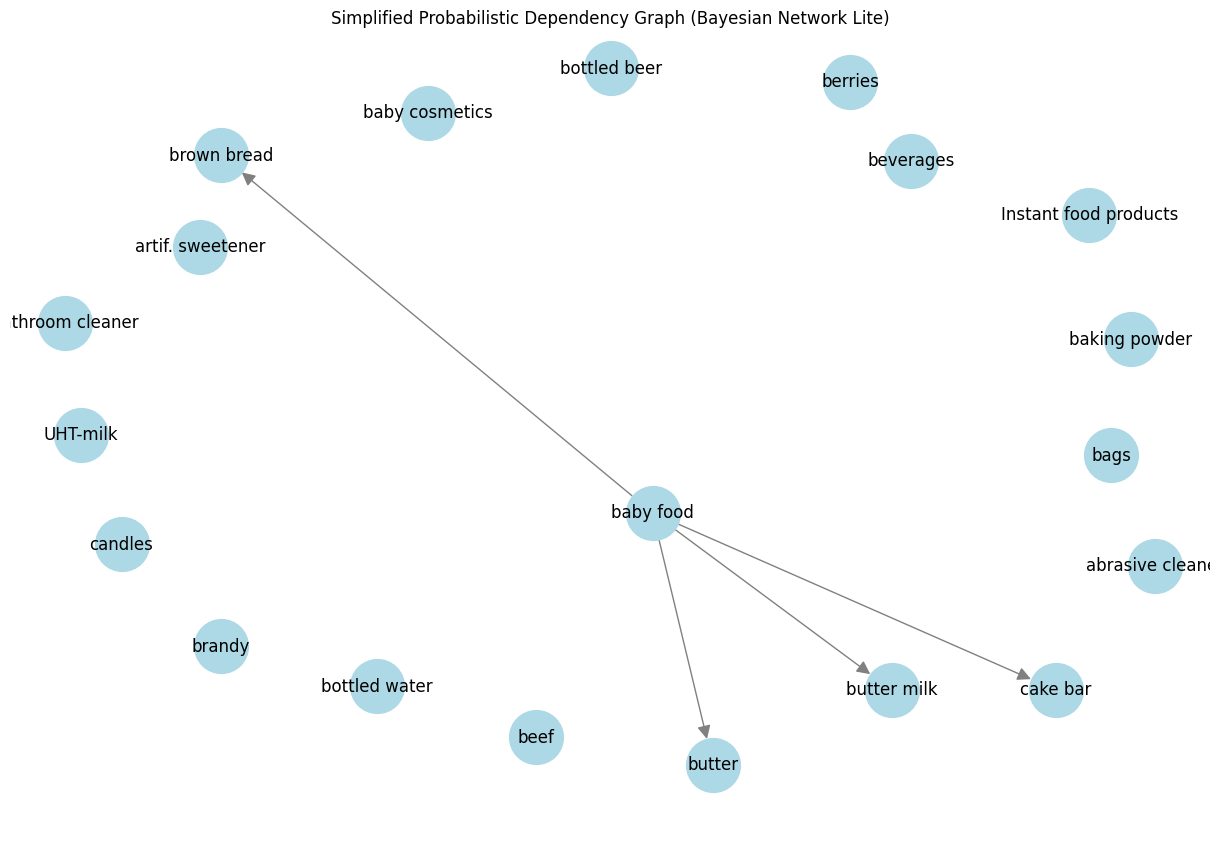

Items likely purchased given whole milk:
whole milk         1.000000
kitchen utensil    0.750000
honey              0.733333
cereals            0.642857
rice               0.613333
rubbing alcohol    0.600000
cocoa drinks       0.590909
pudding powder     0.565217
jam                0.547170
baking powder      0.522989
Name: whole milk, dtype: float64


In [169]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

#  Ensure integer encoding
df_int = df.astype(int)

#  Compute pairwise co-occurrence
co_occur = df_int.T.dot(df_int)

# Compute support
support = df_int.sum(axis=0) / len(df_int)

# Compute conditional probability P(B|A) for all pairs
conditional_prob = pd.DataFrame(index=df_int.columns, columns=df_int.columns, dtype=float)
for a, b in itertools.product(df_int.columns, repeat=2):
    if df_int[a].sum() > 0:
        conditional_prob.loc[a, b] = co_occur.loc[a, b] / df_int[a].sum()
    else:
        conditional_prob.loc[a, b] = 0.0

#  Threshold for "strong" dependencies to mimic DAG edges
threshold = 0.5  # e.g., P(B|A) > 0.5
edges = [(a, b) for a, b in itertools.product(df_int.columns, df_int.columns)
         if a != b and conditional_prob.loc[a, b] > threshold]

#  Build a directed graph
G = nx.DiGraph()
G.add_nodes_from(df_int.columns)
G.add_edges_from(edges)

# Visualize a small subgraph (top 20 items with most edges)
top_items = df_int.columns[:20]
subG = G.subgraph(top_items)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subG, k=0.5)
nx.draw(subG, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, arrowsize=20)
plt.title("Simplified Probabilistic Dependency Graph (Bayesian Network Lite)")
plt.show()

# Inspect top conditional probabilities for a sample item
sample_item = 'whole milk'
print(f"Items likely purchased given {sample_item}:")
print(conditional_prob[sample_item].sort_values(ascending=False).head(10))


# 24.3.8 Classification and Regression Rules

**Objective:**  
Identify rules that predict a **dependent attribute** ($Y$) based on one or more **predictor attributes** ($X_1, ..., X_k$).

---

## **Rule Structure**

$$
P_1(X_1) \wedge P_2(X_2) \wedge \dots \wedge P_k(X_k) \Rightarrow Y = c
$$

Where:

- $X_1, ..., X_k$: predictor attributes  
- $Y$: dependent attribute (to be predicted)  
- $P_i(X_i)$: predicates on predictor attributes, either:
  - **Numerical:** $l_i \leq X_i \leq h_i$  
  - **Categorical:** $X_i \in \{v_1, ..., v_j\}$

---

## **Types of Rules**

1. **Classification Rules:** Predict a **categorical** dependent attribute.  
   - Example:  
   $$
   (16 \leq age \leq 25) \wedge (cartype \in \{Sports, Truck\}) \Rightarrow highrisk = true
   $$

2. **Regression Rules:** Predict a **numerical** dependent attribute.  
   - Example: $Y = f(X_1, ..., X_k)$, where RHS is a function of predictors.

---

## **Support and Confidence**

- **Support:** Percentage of tuples satisfying both LHS and RHS.  
- **Confidence:** Percentage of tuples satisfying RHS among those satisfying LHS.

---

## **Key Difference from Association Rules**

- Handles both **continuous** and **categorical** predictors, not just set-valued items.  
- Can model **functional relationships** in addition to simple co-occurrences.

---

## **Applications**

- **Classification:** Scientific experiment outcomes, direct mail targeting, insurance risk assessment.  
- **Regression:** Financial forecasting (e.g., commodity prices), medical prognosis (e.g., likelihood of tumor malignancy).


In [171]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Define target item (dependent variable)
target_item = 'whole milk'  # predict if 'whole milk' is purchased
X = df.drop(columns=[target_item])
y = df[target_item].astype(int)  # 0/1

#Split dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a decision tree classifier (interpretable as rules)
clf = DecisionTreeClassifier(max_depth=4, random_state=42)  # shallow tree = simpler rules
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Optional: Extract simple rules
from sklearn.tree import export_text
rules = export_text(clf, feature_names=list(X.columns))
print(rules)


              precision    recall  f1-score   support

           0       0.77      0.97      0.86      2229
           1       0.48      0.09      0.16       722

    accuracy                           0.75      2951
   macro avg       0.62      0.53      0.51      2951
weighted avg       0.70      0.75      0.68      2951

|--- root vegetables <= 0.50
|   |--- other vegetables <= 0.50
|   |   |--- curd <= 0.50
|   |   |   |--- brown bread <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- brown bread >  0.50
|   |   |   |   |--- class: 0
|   |   |--- curd >  0.50
|   |   |   |--- pastry <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- pastry >  0.50
|   |   |   |   |--- class: 1
|   |--- other vegetables >  0.50
|   |   |--- curd <= 0.50
|   |   |   |--- yogurt <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- yogurt >  0.50
|   |   |   |   |--- class: 0
|   |   |--- curd >  0.50
|   |   |   |--- beverages <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- beverage

# 24.4 Tree-Structured Rules

**Concept:**  
Tree-structured rules focus on **classification and regression** tasks using a hierarchical tree representation.

- **Classification trees / Decision trees:** Categorical dependent attribute ($Y$)  
- **Regression trees:** Numerical dependent attribute ($Y$)  

**Interpretability:** Each path from root to leaf represents a single rule.

---

## **Example: Decision Tree for Insurance Risk**

| Age   | Car Type      | Risk Prediction |
|-------|---------------|----------------|
| ≤ 25  | Sedan         | Low            |
| ≤ 25  | Sports/Truck  | High           |
| > 25  | *             | Low            |

**Rule Extraction:**  
Each root-to-leaf path corresponds to a conjunction of predicates:

$$
(age \leq 25) \wedge (cartype = Sedan) \Rightarrow highrisk = false
$$

---

## **Decision Tree Construction**

- **Internal nodes:** Splitting attributes (predictors)  
- **Edges:** Predicates on the splitting attribute  
- **Leaves:** Predicted value of the dependent attribute  

Typically **binary trees** are used, but trees of higher degree are possible.

---

## **Algorithm (Top-Down, Greedy)**

**Phases:**

1. **Growth Phase:** Build a large tree to fit the data accurately.  
2. **Pruning Phase:** Remove overspecialized nodes to generate more general rules.

- **Split selection method:** Determines the best attribute and predicate at each node.

---

## **Example Dataset**

| age | cartype | highrisk |
|-----|---------|----------|
| 23  | Sedan   | false    |
| 30  | Sports  | false    |
| 36  | Sedan   | false    |
| 25  | Truck   | true     |
| 30  | Sedan   | false    |
| 23  | Truck   | true     |
| 30  | Truck   | false    |
| 25  | Sports  | true     |
| 18  | Sedan   | false    |

Tree structure is derived by applying splitting criteria on **age** and **cartype**.

---

## **Key Points**

- Tree-structured rules are **interpretable, accurate, and widely used**.  
- Induction involves **top-down recursive splitting** and **post-pruning**.  
- Each leaf node represents a **single rule** for classification or regression.


In [172]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report

# Define the target (dependent attribute)
target_item = 'whole milk'
X = df.drop(columns=[target_item])  # predictors: all other items
y = df[target_item].astype(int)     # 0/1

#  Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#  Train a decision tree (interpretable as tree-structured rules)
clf = DecisionTreeClassifier(max_depth=5, random_state=42)  # limit depth for simplicity
clf.fit(X_train, y_train)

# Evaluate predictive performance
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

#  Extract tree-structured rules
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)


              precision    recall  f1-score   support

           0       0.77      0.96      0.86      2229
           1       0.50      0.12      0.20       722

    accuracy                           0.76      2951
   macro avg       0.64      0.54      0.53      2951
weighted avg       0.71      0.76      0.70      2951

|--- root vegetables <= 0.50
|   |--- other vegetables <= 0.50
|   |   |--- curd <= 0.50
|   |   |   |--- brown bread <= 0.50
|   |   |   |   |--- whipped/sour cream <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- whipped/sour cream >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- brown bread >  0.50
|   |   |   |   |--- newspapers <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- newspapers >  0.50
|   |   |   |   |   |--- class: 1
|   |   |--- curd >  0.50
|   |   |   |--- pastry <= 0.50
|   |   |   |   |--- cat food <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cat food >  0.50
|   |   |   |   |   |--- class

# 24.4.2 Building Decision Trees for Large Databases

**Problem:**  
Standard decision tree algorithms assume the dataset fits in memory. For very large databases, loading all data into memory is often infeasible.

---

## **Key Insight**

- Split selection at a node only requires **aggregated information** for each predictor attribute, not the full dataset.  
- This aggregated information is called an **AVC set (Attribute-Value, Classlabel)**.

---

## **AVC Set**

- For a predictor attribute at a node, the AVC set records counts of each dependent attribute value for each value of the predictor.  
- **Example:** For age, the AVC set counts how many high-risk vs low-risk customers exist for each age.  
- The **AVC group** at a node is the collection of AVC sets for all predictor attributes.

---

## **Algorithm Overview (Memory-Efficient Induction)**

1. Scan the database and compute the **AVC group** for the current node.  
2. Use the AVC group to determine the **best splitting attribute** and predicates.  
3. Partition the database according to the split and recursively apply the same steps to child nodes.

---

## **Advantages**

- Memory usage depends on the **number of distinct attribute values**, not the total number of records.  
- Enables decision tree induction on very large datasets.  
- Produces the **same splitting decisions** as if the full dataset were in memory.

---

## **Summary**

Decision trees can scale to large datasets by leveraging **aggregated counts (AVC sets)** rather than raw data, preserving accuracy while significantly reducing memory requirements.


In [174]:
import pandas as pd

target_item = 'whole milk'
predictors = df.drop(columns=[target_item]).columns
y = df[target_item].astype(int)

#  Compute AVC sets with explicit boolean column handling
avc_sets = {}
for attr in predictors:
    avc = df.groupby(attr)[target_item].value_counts().unstack(fill_value=0)
    avc_sets[attr] = avc

# Display AVC sets for first few predictors
for attr in list(predictors)[:5]:
    print(f"\nAVC set for {attr}:\n", avc_sets[attr])

#  Memory-efficient split selection (illustration)
# Sum over True and False columns explicitly
best_attr = max(
    avc_sets,
    key=lambda a: avc_sets[a][True].sum() - avc_sets[a][False].sum()
)
print(f"\nBest splitting attribute (approximate): {best_attr}")

#  Partition dataset based on best attribute
left = df[df[best_attr] == 0]
right = df[df[best_attr] == 1]

print(f"\nPartition sizes -> left: {len(left)}, right: {len(right)}")



AVC set for Instant food products:
 whole milk             False  True 
Instant food products              
False                   7273   2483
True                      49     30

AVC set for UHT-milk:
 whole milk  False  True 
UHT-milk                
False        7032   2474
True          290     39

AVC set for abrasive cleaner:
 whole milk        False  True 
abrasive cleaner              
False              7303   2497
True                 19     16

AVC set for artif. sweetener:
 whole milk        False  True 
artif. sweetener              
False              7301   2502
True                 21     11

AVC set for baby cosmetics:
 whole milk      False  True 
baby cosmetics              
False            7319   2510
True                3      3

Best splitting attribute (approximate): Instant food products

Partition sizes -> left: 9756, right: 79


# 24.5 Clustering

**Objective:**  
Partition records into groups (**clusters**) such that:

- Records within a cluster are **similar**.  
- Records across clusters are **dissimilar**.  

**Similarity** is measured via a distance function, which depends on the application.

---

## **Example**

For `CustomerInfo(age, salary)` plotted in 2D:

- **Cluster A:** Young, low salary  
- **Cluster B:** Young, high salary  
- **Cluster C:** Older, high salary

---

## **Cluster Representation**

- **Center ($C$):** Mean of records in the cluster  
- **Radius ($R$):** Measure of spread around the center

$$
C = \frac{1}{n} \sum_{i=1}^{n} r_i, \quad
R = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (r_i - C)^2}
$$

---

## **Types of Clustering Algorithms**

1. **Partitional:** Partition data into $k$ clusters (user-specified), optimizing a quality measure.  
2. **Hierarchical:** Build a sequence of partitions, merging or splitting clusters iteratively until one final clustering is reached.

---

## **BIRCH Algorithm (for Large Databases)**

**Design Goals:**

- Handle very large datasets in a **single scan**.  
- Operate with **limited main memory**.

**Key Parameters:**

- $k$: Maximum number of cluster summaries in memory  
- $\varepsilon$: Radius threshold for clusters  
  - Small $\varepsilon$ → many small clusters  
  - Large $\varepsilon$ → fewer, larger clusters

---

## **Algorithm Steps**

1. **Assign record to closest cluster:**  
   - Compute distance from record $r$ to all cluster centers  
   - Let $i$ be the nearest cluster

2. **Check cluster compactness:**  
   - Compute new radius $R'_i$ if $r$ is added  
   - If $R'_i \leq \varepsilon$ → add $r$ to cluster $i$  
   - If $R'_i > \varepsilon$ → create a new cluster for $r$

3. **Memory management:**  
   - If maximum cluster summaries $k$ reached, increase $\varepsilon$  
   - Merge existing clusters if possible  
   - Expand clusters to accommodate more records

**Data Structure:**  
- Uses a balanced in-memory tree (similar to B+ tree) for fast nearest-cluster identification

---

## **Summary**

- BIRCH maintains **compact clusters dynamically**  
- Scales well to **large datasets** with limited memory  
- **One-pass algorithm** with memory-efficient cluster summaries


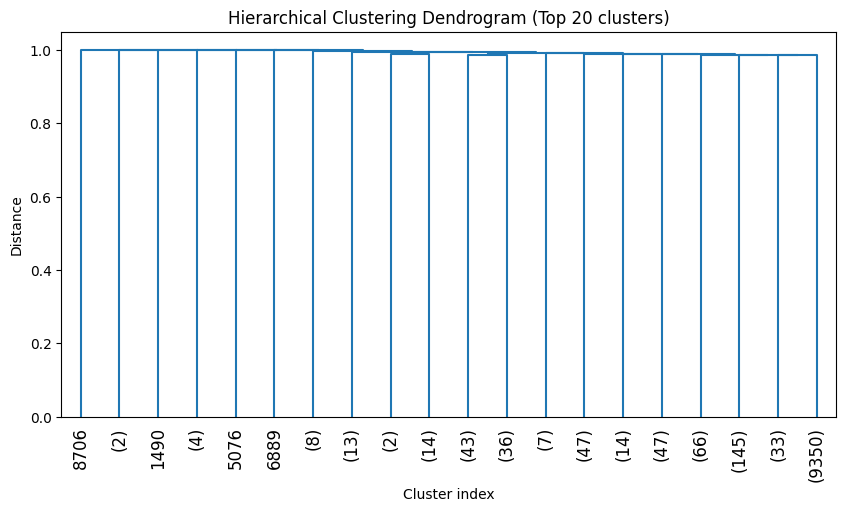

cluster
3    9827
2       4
1       2
4       1
5       1
Name: count, dtype: int64


In [175]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# df: one-hot encoded groceries dataset (9835 x 169)

# Compute Jaccard distance matrix (suitable for binary attributes)
jaccard_dist = pdist(df.values, metric='jaccard')

# Perform hierarchical clustering (agglomerative, average linkage)
Z = linkage(jaccard_dist, method='average')

# Optional: plot dendrogram for first 100 samples (full 9835 may be too large to visualize)
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90.)
plt.title('Hierarchical Clustering Dendrogram (Top 20 clusters)')
plt.xlabel('Cluster index')
plt.ylabel('Distance')
plt.show()

# Step 3: Assign cluster labels for a chosen number of clusters, e.g., k=5
k = 5
cluster_labels = fcluster(Z, k, criterion='maxclust')

# Add cluster labels to DataFrame
df['cluster'] = cluster_labels

# Inspect cluster sizes
print(df['cluster'].value_counts())


# 24.6 Similarity Search over Sequences

**Problem Statement:**  
Many databases store data as **sequences** or **time series**.  
The goal is to retrieve sequences similar to a **user-specified query sequence**, not just exact matches.  
Similarity is measured using a **distance function**.

---

## **Definitions**

- **Data Sequence:**  
  $$
  X = \langle x_1, x_2, ..., x_k \rangle, \quad \text{length} = k
  $$

- **Subsequence:**  
  $$
  Z = \langle z_1, ..., z_j \rangle
  $$  
  Obtained by deleting elements from the front or back.  
  Formally, $Z$ is a subsequence of $X$ if  
  $$
  z_1 = x_i, \; z_2 = x_{i+1}, \; ..., \; z_j = x_{i+j-1}
  $$

- **Distance Between Sequences (Euclidean norm):**  
  For $X = \langle x_1, ..., x_k \rangle$ and $Y = \langle y_1, ..., y_k \rangle$:

  $$
  \|X - Y\| = \sqrt{\sum_{i=1}^{k} (x_i - y_i)^2}
  $$

---

## **Query Model**

- **Query sequence:** $Q$  
- **Threshold:** $\varepsilon$  
- Retrieve all sequences $S$ such that  
  $$
  \|Q - S\| \leq \varepsilon
  $$

---

## **Types of Similarity Queries**

1. **Complete Sequence Matching:**  
   - Query sequence has the **same length** as database sequences.  
   - Retrieve sequences within $\varepsilon$-distance.

2. **Subsequence Matching:**  
   - Query sequence is **shorter** than database sequences.  
   - Goal: find subsequences within $\varepsilon$-distance.  
   - (Not further discussed in this section.)

---

## **Algorithm for Complete Sequence Matching**

### **Naive Approach:**
- Scan the database and compute distance from each sequence to the query.  
- Guarantees finding all sequences within $\varepsilon$-distance.  
- **Inefficient** for large datasets.

### **Index-Based Approach:**
- Represent each sequence as a point in $k$-dimensional space.  
- Build a **multidimensional index** for fast retrieval.  
- Query using a **hyper-rectangle** centered at the query sequence with side length $2 \cdot \varepsilon$.  
- Retrieve all sequences in the hyper-rectangle.  
- **Post-process** to discard sequences beyond $\varepsilon$-distance.

**Advantages:**

- Reduces the number of sequences to examine.  
- Significantly decreases query evaluation time.


In [178]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# Convert boolean df to integers
df_numeric = df.astype(int)

# Define query basket
query_items = ['whole milk', 'yogurt', 'rolls/buns']
query_vec = np.zeros(df_numeric.shape[1])
for item in query_items:
    if item in df_numeric.columns:
        query_vec[df_numeric.columns.get_loc(item)] = 1

# Compute distances
distances_jaccard = cdist(df_numeric.values, query_vec.reshape(1, -1), metric='jaccard').flatten()
distances_euclidean = np.linalg.norm(df_numeric.values - query_vec, axis=1)

# Retrieve top 10 most similar transactions
top_n = 10
top_indices_jaccard = distances_jaccard.argsort()[:top_n]
top_indices_euclidean = distances_euclidean.argsort()[:top_n]

top_transactions_jaccard = df_numeric.iloc[top_indices_jaccard]
top_transactions_euclidean = df_numeric.iloc[top_indices_euclidean]

# Output
print("Top 10 most similar transactions (Jaccard):")
print(top_transactions_jaccard)

print("\nTop 10 most similar transactions (Euclidean):")
print(top_transactions_euclidean)


Top 10 most similar transactions (Jaccard):
      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
5649                      0         0                 0                 0   
797                       0         0                 0                 0   
2314                      0         0                 0                 0   
3743                      0         0                 0                 0   
2254                      0         0                 0                 0   
9579                      0         0                 0                 0   
1482                      0         0                 0                 0   
1640                      0         0                 0                 0   
6007                      0         0                 0                 0   
457                       0         0                 0                 0   

      baby cosmetics  baby food  bags  baking powder  bathroom cleaner  beef  \
5649               0        

# 24.7 Additional Data Mining Tasks

While pattern discovery is central to data mining, several complementary tasks ensure **quality, efficiency, and interpretability**:

---

## **Dataset Selection**

- Identify which datasets are **relevant** for the mining task.  
- Critical because mining irrelevant data **wastes resources** and can produce **misleading results**.

---

## **Feature Selection**

- Choose the most **informative attributes** (predictors) to include.  
- Benefits:  
  - Reduces noise  
  - Improves model interpretability  
  - Accelerates computation

---

## **Sampling**

- For very large datasets, analyzing **samples** can make the problem tractable.  
- **Pros:** Detailed analysis feasible on large datasets  
- **Cons:** Risk of missing important patterns if the sample is not representative  
- Note: Database support for **statistically sound sampling** is limited but improving

---

## **Visualization**

- Visual methods help understand **complex patterns, relationships, and anomalies**  
- Often used as a **post-mining tool** to interpret results and communicate findings effectively

---

# 24.8 Key Points to Review

### **Data Mining Overview**

- Iterative process:  
  **Data selection → Preprocessing → Transformation → Mining → Interpretation**  
- Goal: Identify **interesting patterns** from large datasets

---

### **Frequent Itemsets & Association Rules**

- **Itemset:** Collection of items in a transaction  
- **Frequent itemset:** Appears in ≥ minimum percentage of transactions  
- **A priori property:** All subsets of a frequent itemset are also frequent  
- **Iceberg queries:** Aggregation queries with HAVING clauses; leverage **bottom-up pruning**  
- **Association rule:** LHS ⇒ RHS, quantified by **support** and **confidence**  
- **Generalized rules:** Include ISA hierarchies or complex groupings (e.g., customer groups, calendars)  
- **Sequential patterns:** Ordered sequences of itemsets (e.g., purchase sequences)  
- **Limitation:** Association rules indicate **correlation**, not causation  
  - Use **Bayesian networks** for causal modeling

---

### **Classification & Regression Rules**

- Can involve **numerical and categorical attributes**  
- Often represented as **trees**:  
  - **Decision tree:** Paths from root → leaf represent rules  
  - **Split selection methods** and **AVC sets** enable efficient tree construction, even for large datasets

---

### **Clustering**

- Partition records into clusters such that **within-cluster similarity** is high and **between-cluster similarity** is low  
- Similarity typically measured via a **distance function**

---

### **Similarity Search over Sequences**

- Find sequences similar to a query sequence within a distance threshold $\varepsilon$  
- Techniques:  
  - Represent sequences as points in **multidimensional space**  
  - Use **multidimensional indexing** to limit candidate sequences

---

### **Additional Considerations**

- **Dataset and feature selection, sampling, and visualization** remain crucial to enhance **data mining outcomes and interpretability**
